# Initiate

In [1]:
from openai import OpenAI
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
import seaborn as sns

In [ ]:
openrouter_api = "Your OpenRouter API Key Here"
client = OpenAI(
  base_url="https://openrouter.ai/api/v1",
  api_key=openrouter_api,
)

# QA Functions (Run to test)

In [ ]:
expert_prompt_4 = 'You are a renowned materials science engineering professor with extensive knowledge in the field. Your students have presented you with a challenging multiple-choice question related to materials science engineering. The question requires a detailed understanding and application of materials science principles. Please read the question carefully and provide a step-by-step explanation of your reasoning process, calculations, and analysis. Remember, the question has only one correct answer, which could be option (a), (b), (c), (d), etc. After carefully analyzing and calculating, please present the final answer at the end of your explanation. Your goal is to elucidate the concepts and problem-solving techniques in materials science engineering for your students.'

In [ ]:
def Answer_question(Question, Model = 'gpt-3.5-turbo-0613', Temperature = 0.0, expert = True, expert_prompt = expert_prompt_4):
    if expert == True:
        expert_prompt = expert_prompt
    else:
        expert_prompt = ''
    response = client.chat.completions.create(
      model= Model,
      messages=[{"role": "system", "content": expert_prompt},
                {"role": "user", "content": Question},
                ],
      temperature=Temperature,
    )
    return response.choices[0].message.content


def Check_answer(Question, Answer, right_answer, Model = 'openai/gpt-4o-2024-11-20', Temperature = 0.0):
    response = client.chat.completions.create(
      model= Model,
      messages=[{"role": "system", "content": 'You are to read the following text, which is the answer to a multiple choices question. The text should state the final answer (option (a), (b), (c), or (d)). You are to compare the stated answer with the correct answer: ' + str(right_answer) + '. If the stated answer is correct, please type 1, otherwise type 0. '+ 'If the final answer is not one of the options or report multiple options, it is considered wrong (you should type 0)' + ' Do not type anything else other than 1 or 0.'},
                {"role": "user", "content":  'Answer: ' + Answer + '\nQuestion: ' + Question + '\nRight Answer: ' + str(right_answer) + '\n1 or 0: '},
                ],
      temperature=Temperature,
      max_tokens=1,
    )
    return response.choices[0].message.content

# Testing (Skip if tested)

In [ ]:
mcq_df = pd.read_csv('MSE-MCQs_degradation_study.csv',encoding='unicode_escape')

In [ ]:
# Define your model here
Model = "Your Model"

In [ ]:
import time

# Define the columns and run frequencies
run_once_columns = [
    'Unit Mixing 1', 'Unit Mixing 2', 'Unit Mixing 3',
    'Sentence Reordering 1', 'Sentence Reordering 2', 'Sentence Reordering 3',
    'Superfluous Info 1', 'Superfluous Info 2', 'Superfluous Info 3'
]

run_three_times_columns = ['Replace Synonyms', 'Distractive Info']

# Ensure 'Status' column exists
if 'Status' not in mcq_df.columns:
    mcq_df['Status'] = ''

# Function to check if all runs for a column are completed
def is_all_runs_done(status, column):
    return any(f'Done_{column}_Run3' in status for column in run_three_times_columns)

# Function to process questions
def process_questions():
    count = 0

    # First, check if any multi-run column has reached Run3
    skip_processing = False
    for idx, status in enumerate(mcq_df['Status']):
        if is_all_runs_done(status, run_three_times_columns):
            skip_processing = True
            break  # If Run3 is done for any, we skip previous columns

    # Process columns that run once (only if we are not skipping)
    if not skip_processing:
        for column in run_once_columns:
            for idx, Question in enumerate(mcq_df[column]):
                status = mcq_df.loc[idx, 'Status']

                if f'Done_{column}' in status:  # Skip if already processed
                    continue

                try:
                    Answerwo = Answer_question(Question, Model=Model, expert=False)
                    mcq_df.loc[idx, f'Answer w/o Expert {column}'] = Answerwo
                    mcq_df.loc[idx, 'Status'] += f'Done_{column};'  # Append status instead of overwriting
                    time.sleep(1)
                    count += 1
                    print(f'Processed {count}: {column}')
                except Exception as e:
                    print(f'Error at {column}, idx {idx}: {e}')
                    return  # Exit to allow resuming later

    # Process columns that run three times
    for column in run_three_times_columns:
        for idx, Question in enumerate(mcq_df[column]):
            status = mcq_df.loc[idx, 'Status']

            if f'Done_{column}_Run3' in status:  # If final run is done, skip
                continue

            for i in range(1, 4):  # Run three times
                if f'Done_{column}_Run{i}' in status:  # Skip if already processed
                    continue

                try:
                    Answerwo = Answer_question(Question, Model=Model, expert=False)
                    mcq_df.loc[idx, f'Answer w/o Expert {column} Run {i}'] = Answerwo
                    mcq_df.loc[idx, 'Status'] += f'Done_{column}_Run{i};'  # Append instead of overwrite
                    time.sleep(1)
                    count += 1
                    print(f'Processed {count}: {column} Run {i}')
                except Exception as e:
                    print(f'Error at {column} Run {i}, idx {idx}: {e}')
                    return  # Exit to allow resuming later

# Call the processing function
process_questions()

# Save progress
mcq_df.to_csv('Revision-MSE-MCQs_degradation_study_GPT-4o (2024-11-20).csv', index=False)

mcq_df


# Check (Skip if checked)

In [ ]:
# Ensure necessary columns exist in the DataFrame
if 'Status' not in mcq_df.columns:
    mcq_df['Status'] = ''  # Track progress
if 'True Answer' not in mcq_df.columns:
    raise ValueError("'True Answer' column is required in mcq_df.")

# Function to check answers
def check_all_answers():
    count = 0

    # Identify all columns that contain "Answer w/" in their names
    answer_columns = [col for col in mcq_df.columns if 'Answer w/' in col]

    # Loop through all rows
    for idx, row in mcq_df.iterrows():
        # Skip rows already fully checked
        if mcq_df.loc[idx, 'Status'] == 'Checked_All':
            continue

        # Process each "Answer w/" column
        for col in answer_columns:
            # Skip if the column is empty or already checked
            if pd.isna(row[col]) or row[col] == 'unknown':
                mcq_df.loc[idx, col.replace('Answer', 'Check')] = '0'
                continue

            # Determine the specific question column corresponding to this answer
            question_col = col.split('Answer w/o Expert ')[-1].split(' Run')[0].strip()
            Question = row[question_col] if question_col in mcq_df.columns else None
            if Question is None:
                print(f"Missing question column: {question_col} for row {idx}")
                mcq_df.loc[idx, col.replace('Answer', 'Check')] = 'error'
                continue

            # Retrieve the answer and the correct answer
            Answer = row[col]
            right_answer = row['True Answer']

            try:
                # Check the answer
                check_result = Check_answer(Question, Answer, right_answer)

                # Save the check result
                mcq_df.loc[idx, col.replace('Answer', 'Check')] = check_result
                count += 1
                print(f"Checked {count}: Row {idx}, Question {question_col}, Column {col}")

                # Pause to prevent API rate limits
                time.sleep(1)
            except Exception as e:
                print(f"Error checking Row {idx}, Column {col}: {e}")
                mcq_df.loc[idx, col.replace('Answer', 'Check')] = 'error'
                return  # Exit to allow resumption

        # Mark the row as fully checked
        mcq_df.loc[idx, 'Status'] = 'Checked_All'

    print("All answers checked.")

# Save progress to a CSV file
def save_checkpoint(file_name='Revision-MSE-MCQs_degradation_study_GPT-4o (2024-11-20)_checked.csv'):
    mcq_df.to_csv(file_name, index=False)
    print(f"Checkpoint saved to {file_name}")

# Run the checking function
try:
    check_all_answers()
except Exception as main_error:
    print(f"Processing stopped due to error: {main_error}")

# Save the final checkpoint
save_checkpoint()

# Plot

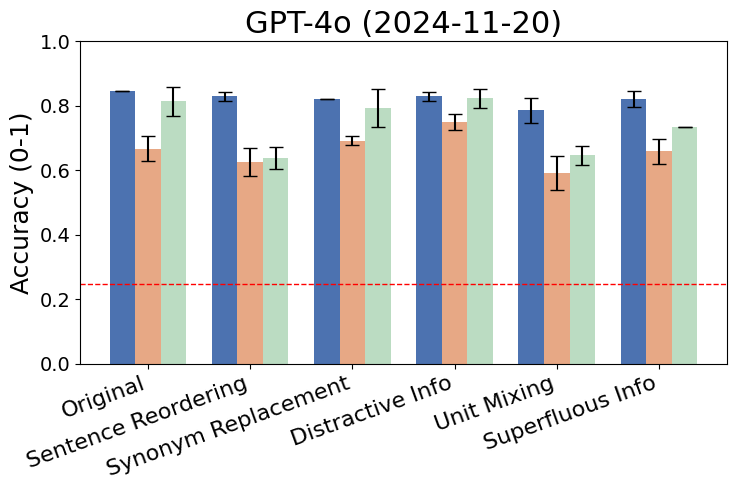

In [2]:
# Load data
data = pd.read_csv('MSE-MCQs_degradation_study_GPT-4o (2024-11-20)_checked.csv', encoding='cp1252')
data_original = pd.read_csv('mcq_final_GPT-4o (2024-11-20)_checked.csv', encoding='cp1252')

# Extract columns containing "Check w/o Expert" from original data
columns_needed = [col for col in data_original.columns if 'Check w/o Expert' in col]

# Rename columns to specify "Original"
data_original.rename(columns={col: col.replace('Check w/o Expert', 'Check w/o Expert Original') for col in columns_needed}, inplace=True)
columns_needed_renamed = [col.replace('Check w/o Expert', 'Check w/o Expert Original') for col in columns_needed]

# Concatenate data with original check columns
data = pd.concat([data, data_original[columns_needed_renamed]], axis=1)

# Extract columns that contain "Check"
check_repeat_columns = [col for col in data.columns if 'Check' in col]

# Function to categorize test types
def extract_test_type(column_name):
    if 'Original' in column_name:
        return 'Original'
    elif 'Sentence Reordering' in column_name:
        return 'Sentence Reordering'
    elif 'Replace Synonyms' in column_name:
        return 'Synonym Replacement'
    elif 'Distractive Info' in column_name:
        return 'Distractive Info'
    elif 'Unit Mixing' in column_name:
        return 'Unit Mixing'
    elif 'Superfluous Info' in column_name:
        return 'Superfluous Info'
    else:
        return 'Other'

# Group data by difficulty
grouped_data_by_difficulty = data.groupby('Difficulty')

# Compute correctness
results = []
for difficulty, group in grouped_data_by_difficulty:
    for check_column in check_repeat_columns:
        test_type = extract_test_type(check_column)
        correctness = group[check_column].sum() / len(group)
        results.append({'Test Type': test_type, 'Difficulty': difficulty, 'Correctness': correctness})

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Compute averages and standard deviations
mcq_df = results_df.groupby(['Test Type', 'Difficulty']).agg(
    Average_Correctness=('Correctness', 'mean'),
    Std_Dev_Correctness=('Correctness', 'std')
).reset_index()

# Define correct test type order
test_type_order = [
    "Original",
    "Sentence Reordering",
    "Synonym Replacement",
    "Distractive Info",
    "Unit Mixing",
    "Superfluous Info"
]

# Ensure "Original" is always first, then order the rest by accuracy in Easy
easy_order = mcq_df[mcq_df['Difficulty'] == 'Easy'].sort_values('Average_Correctness', ascending=False)['Test Type'].tolist()

# Ensure predefined test type order is respected
sorted_test_types = ["Original"] + [t for t in test_type_order if t in easy_order and t != "Original"]

# Set categorical ordering
mcq_df['Test Type'] = pd.Categorical(mcq_df['Test Type'], categories=sorted_test_types, ordered=True)
mcq_df = mcq_df.sort_values(['Test Type', 'Difficulty']).reset_index(drop=True)

# Plot
fig, ax = plt.subplots(figsize=(7.5, 5))

# Unique test types and difficulties
test_types = mcq_df['Test Type'].unique()
difficulties = ['Easy', 'Medium', 'Hard']
colors = sns.color_palette('deep', len(difficulties))

# Plot each difficulty level in order
for i, difficulty in enumerate(difficulties):
    difficulty_data = mcq_df[mcq_df['Difficulty'] == difficulty]
    bar_positions = range(len(test_types))
    alpha = 1 - (i * 0.3)  # Adjust transparency for difficulty level

    # Plot bars with error bars
    ax.bar(
        [pos + 0.25 * i for pos in bar_positions],
        difficulty_data['Average_Correctness'],
        yerr=difficulty_data['Std_Dev_Correctness'],
        label=difficulty,
        width=0.25,
        color=colors[i],
        align='center',
        capsize=5,
        alpha=alpha
    )

# Set labels and title
ax.set_ylabel('Accuracy (0-1)', fontsize=18)
ax.set_title('GPT-4o (2024-11-20)', fontsize=22)
ax.set_xticks([r + 0.25 for r in range(len(test_types))])
ax.set_xticklabels(test_types, fontsize=16, ha='right', rotation=20)
ax.tick_params(axis='y', labelsize=14)
ax.set_ylim(0, 1)

# Add baseline score
ax.axhline(y=0.246, color='red', linestyle='--', linewidth=1, label='Baseline Score')

# Add legend
#ax.legend(title='Difficulty', fontsize=13, title_fontsize=14, loc='upper right')

plt.tight_layout()
plt.show()


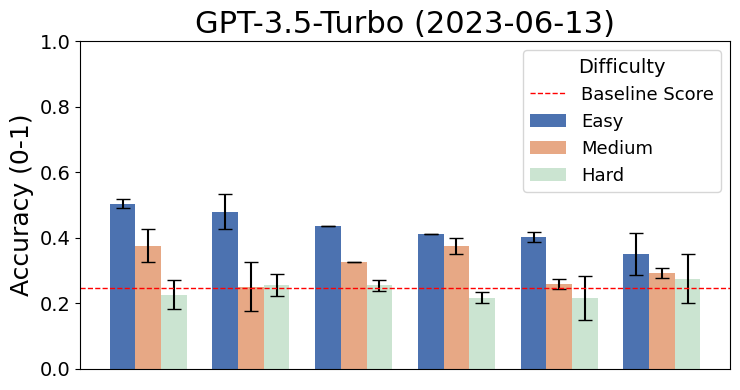

In [3]:
data = pd.read_csv('mcq_final_GPT-3.5-Turbo (2023-06-13)_checked.csv')
# Extracting all columns that contain "Check" and have a repeat number (1, 2, 3)
check_repeat_columns = [col for col in data.columns if 'Check' in col]
#print(check_repeat_columns)
# Function to extract the base test type from the column name
def extract_test_type(column_name):
    #print(column_name)
    if 'Original' in column_name:
        return 'Original'
    elif 'Check' and 'Similarity' in column_name:
        #print(' '.join(column_name.split()[1:5]))
        return ' '.join(column_name.split()[1:5])
    elif 'Reorder' in column_name:
        #print(' '.join(column_name.split()[1:5]))
        return 'Sentence Reordering'
    elif 'Check' and 'Random' in column_name:
        #print(' '.join(column_name.split()[1:4]))
        return ' '.join(column_name.split()[1:3])
    elif 'Replace' in column_name:
        return 'Synonym Replacement'
    elif 'Mixed Unit' in column_name:
        return 'Unit Mixing'
    else:
        return ' '.join(column_name.split()[1:-3])


# Grouping data by 'Difficulty'
grouped_data_by_difficulty = data.groupby('Difficulty')

# Calculating Correctness, Average and Standard Deviation
results = []

for difficulty, group in grouped_data_by_difficulty:
    for check_column in check_repeat_columns:
        test_type = extract_test_type(check_column)
        #print(test_type)
        # Calculate the number of '1's over the total number of rows for each check column
        correctness = group[check_column].sum() / len(group)

        # Store the results
        results.append({
            'Test Type': test_type,
            'Difficulty': difficulty,
            'Correctness': correctness
        })

# Convert results to a DataFrame and rename to mcq_df
mcq_df = pd.DataFrame(results)

# Compute the average and standard deviation for each type of test across the three repeats
mcq_df = mcq_df.groupby(['Test Type', 'Difficulty']).agg(
    Average_Correctness=('Correctness', 'mean'),
    Std_Dev_Correctness=('Correctness', 'std')
).reset_index()

# reorder the rows in the dataframe by having "Original" first, then "Mixed Unit", "Reordered Sentences", "Superfluous Info", "Distractive Info"
mcq_df = mcq_df.reindex([3,5,4,6,8,7,12,14,13,0,2,1,15,17,16,9,11,10])

# Using matplotlib for plotting
fig, ax = plt.subplots(figsize=(7.5, 4))

# Unique test types and difficulties for plotting
test_types = mcq_df['Test Type'].unique()
difficulties = mcq_df['Difficulty'].unique()
#colors = ['blue', 'green', 'red']  # Colors for each difficulty level
# use a different set of colors for each difficulty level
colors = sns.color_palette('deep', len(difficulties))

# Plotting each test type with error bars for different difficulties
for i, difficulty in enumerate(difficulties):
    # Filter data for each difficulty
    difficulty_data = mcq_df[mcq_df['Difficulty'] == difficulty]
    
    # Create bar positions for each test type
    bar_positions = range(len(test_types))
    if difficulty == 'Easy':
        alpha = 1
    elif difficulty == 'Medium':
        alpha = 0.7
    else:
        alpha = 0.3
    # Plot bars with error bars
    ax.bar([pos + 0.25 * i for pos in bar_positions], difficulty_data['Average_Correctness'], 
           yerr=difficulty_data['Std_Dev_Correctness'], label=difficulty, 
           width=0.25, color=colors[i], align='center', capsize=5, alpha=alpha)
    # label each bar
    #for pos, correctness, error_vals in zip(bar_positions, difficulty_data['Average_Correctness'], difficulty_data['Std_Dev_Correctness']):
    #    ax.text(pos + 0.25 * i, correctness + 0.02+ error_vals, f'{correctness:.2f}', ha='center', va='bottom')


# Setting labels and titles
#ax.set_xlabel('Test Type')
ax.set_ylabel('Accuracy (0-1)', fontsize=18)
ax.set_title('GPT-3.5-Turbo (2023-06-13)', fontsize=22)
#ax.set_xticks([r + 0.25 for r in range(len(test_types))])
ax.set_xticks([])
#ax.set_xticklabels(test_types, fontsize=18, ha='right', rotation=20)
#ax.set_xticklabels(test_types, fontsize=16, ha='right', rotation=20)
# set y tick size
ax.tick_params(axis='y', labelsize=14)
ax.set_ylim(0,1)
# do not show y ticks
#ax.yaxis.set_ticks_position('none')

# plot a horizontal line at y = 0.25
ax.axhline(y=0.246, color='red', linestyle='--', linewidth=1, label='Baseline Score')
ax.legend(title='Difficulty',fontsize=13, title_fontsize='14', loc = 'upper right')
# label the horizontal line saying "Baseline Score"
#ax.text(0, 0.28, 'Baseline Score', ha='right', va='bottom', color='red')
plt.tight_layout()
plt.show()